In [13]:
%pip install -U scikit-image

Note: you may need to restart the kernel to use updated packages.


In [26]:
#import libraries

import numpy as np
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from skimage import exposure

In [20]:
# sample photo
sample_photo = "goku.jpg"

# load image and convert to grayscale
image = Image.open(sample_photo).convert("L")

# convert PIL image to NumPy array
image = np.array(image)

print("Image dimensions:", image.shape)
print("Minimum intensity:", image.min())
print("Maximum intensity:", image.max())

Image dimensions: (1000, 1000)
Minimum intensity: 0
Maximum intensity: 255


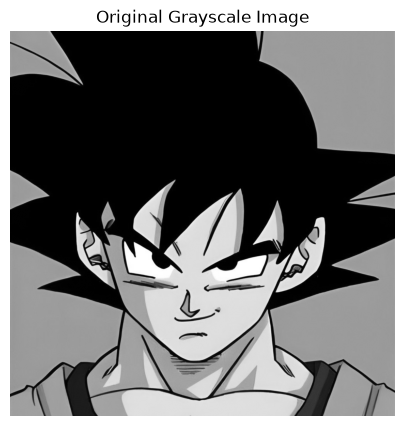

In [23]:
# display image
plt.figure(figsize=(7,5))
plt.imshow(image, cmap="gray")
plt.title("Original Grayscale Image")
plt.axis("off")
plt.show()

Number of histogram bins: 256
Total number of pixels: 1000000


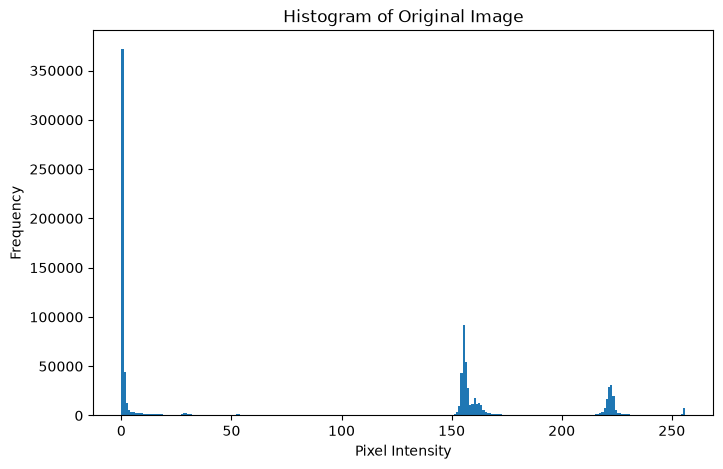

In [31]:
histogram, bins = np.histogram(
    image.flatten(),
    bins=256,
    range=[0, 256]
)

print("Number of histogram bins:", len(histogram))
print("Total number of pixels:", histogram.sum())

plt.figure(figsize=(8,5))
plt.hist(
    image.flatten(),
    bins=256,
    range=[0,256]
)
plt.title("Histogram of Original Image")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
plt.show()

In [32]:
highest_intensity = np.argmax(histogram)

print("Intensity with the largest number of pixels:",
      highest_intensity)

print("Frequency:",
      histogram[highest_intensity])

Intensity with the largest number of pixels: 0
Frequency: 372022


Sum of normalized histogram: 1.0


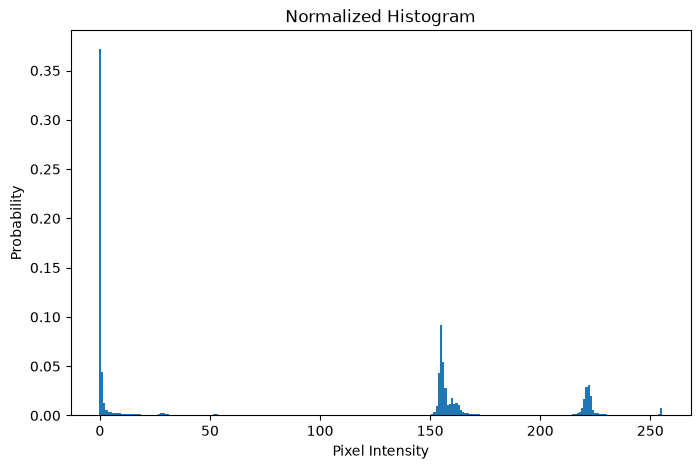

In [34]:
normalized_histogram = histogram / histogram.sum()

print(
    "Sum of normalized histogram:",
    normalized_histogram.sum()
)

plt.figure(figsize=(8,5))

plt.bar(
    range(256),
    normalized_histogram,
    width=1
)

plt.title("Normalized Histogram")
plt.xlabel("Pixel Intensity")
plt.ylabel("Probability")
plt.show()

In [35]:
small_image = np.array([
    [0, 0, 1, 1],
    [1, 2, 2, 3],
    [3, 3, 3, 2],
    [1, 2, 3, 3]
])

hist, bins = np.histogram(
    small_image.flatten(),
    bins=4,
    range=[0,4]
)

normalized = hist / hist.sum()

print("Histogram:")
print(hist)

print("\nNormalized Histogram:")
print(normalized)

print("\nSum:")
print(normalized.sum())

Histogram:
[2 4 4 6]

Normalized Histogram:
[0.125 0.25  0.25  0.375]

Sum:
1.0


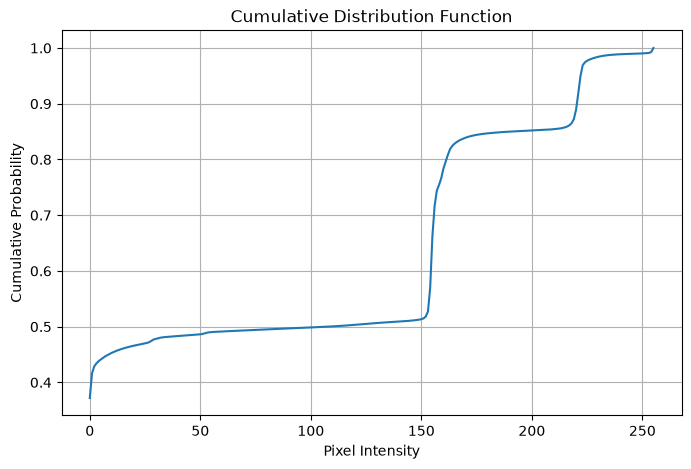

In [36]:
cdf = normalized_histogram.cumsum()

plt.figure(figsize=(8,5))
plt.plot(cdf)

plt.title("Cumulative Distribution Function")
plt.xlabel("Pixel Intensity")
plt.ylabel("Cumulative Probability")

plt.grid()
plt.show()

Input: 0 Output: 94
Input: 25 Output: 119
Input: 50 Output: 124
Input: 75 Output: 126
Input: 100 Output: 127
Input: 125 Output: 128
Input: 150 Output: 130
Input: 175 Output: 215
Input: 200 Output: 217
Input: 225 Output: 249
Input: 250 Output: 252


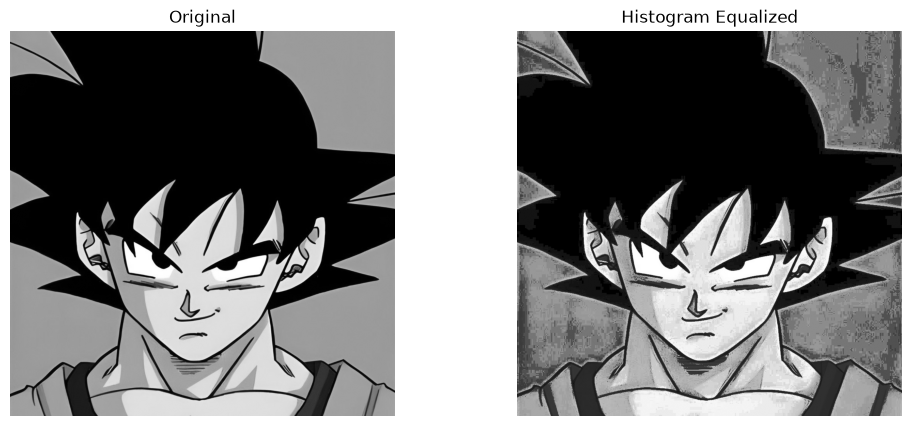

In [37]:
L = 256

equalized_mapping = np.floor(
    (L - 1) * cdf
).astype(np.uint8)

for i in range(0, 256, 25):
    print(
        "Input:", i,
        "Output:", equalized_mapping[i]
    )

equalized_image = equalized_mapping[image]

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(image, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(equalized_image, cmap="gray")
plt.title("Histogram Equalized")
plt.axis("off")

plt.show()